# Probing Semantic Geometry in Word Embeddings

This project investigates whether semantic meaning is reflected in the geometry of pretrained embedding spaces.

Rather than increasing model complexity, I focus on analyzing the structure of representations already learned by a model. This aligns with interpretability research, which asks what information is encoded in embeddings and how it is organized.

Specifically, I examine whether:
- similar concepts cluster together in embedding space,
- semantic categories are partially but imperfectly recoverable using unsupervised methods,
- and whether attributes such as gender emerge as approximately linear directions.

The goal is not to achieve high performance, but to understand the geometric structure underlying learned representations.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.manifold import TSNE
import gensim.downloader as api

In [2]:
model = api.load("glove-wiki-gigaword-50")


[==================================================] 100.0% 66.0/66.0MB downloaded


## Method

I use pretrained GloVe embeddings, which map words to fixed 50-dimensional vectors learned from large text corpora.

Word embeddings represent each word as a vector in a high-dimensional space, allowing semantic relationships to be analyzed geometrically.

To probe the structure of this space, I apply several complementary methods:

- **PCA (Principal Component Analysis):** used to examine global linear structure
- **t-SNE:** used to visualize local neighborhood structure
- **KMeans clustering:** tests whether semantic categories can be recovered through unsupervised partitioning
- **Evaluation metrics (silhouette score, adjusted Rand index):** quantify cluster quality and alignment with known labels
- **Directional probing:** tests whether attributes such as gender correspond to approximately linear directions

These methods allow analysis of both global structure and local organization without modifying the underlying model.

In [33]:
word_categories = {
    "royalty": ["king", "queen", "prince", "princess"],
    "animals": ["dog", "cat", "wolf", "tiger", "lion"],
    "transport": ["car", "truck", "bus", "train", "airplane"],
    "emotion": ["happy", "joyful", "sad", "grief", "angry"]
}

words = [w for group in word_categories.values() for w in group]

valid_words = [w for w in words if w in model]
missing_words = [w for w in words if w not in model]

if missing_words:
    print("Missing words:", missing_words)

embeddings = np.array([model[w] for w in valid_words])

labels = []
for group, ws in word_categories.items():
    for w in ws:
        if w in model:
            labels.append(group)

print("Number of words used:", len(valid_words))

Number of words used: 19


## Dataset Setup

I define a small hand-constructed vocabulary spanning several semantic domains: royalty, animals, transport, and emotion.

This is intentionally a small exploratory dataset rather than a benchmark. The goal is to test whether broad semantic structure is visible even in a simple probe.

The selected categories are designed to span different types of semantic structure. Animals and transport represent concrete, physical objects, while emotion represents a more abstract domain. Royalty captures socially constructed roles with relational structure (e.g., king/queen). This mix allows comparison of how different types of concepts are organized geometrically in embedding space.

In [36]:
pca = PCA(n_components=2)
reduced_pca = pca.fit_transform(embeddings)

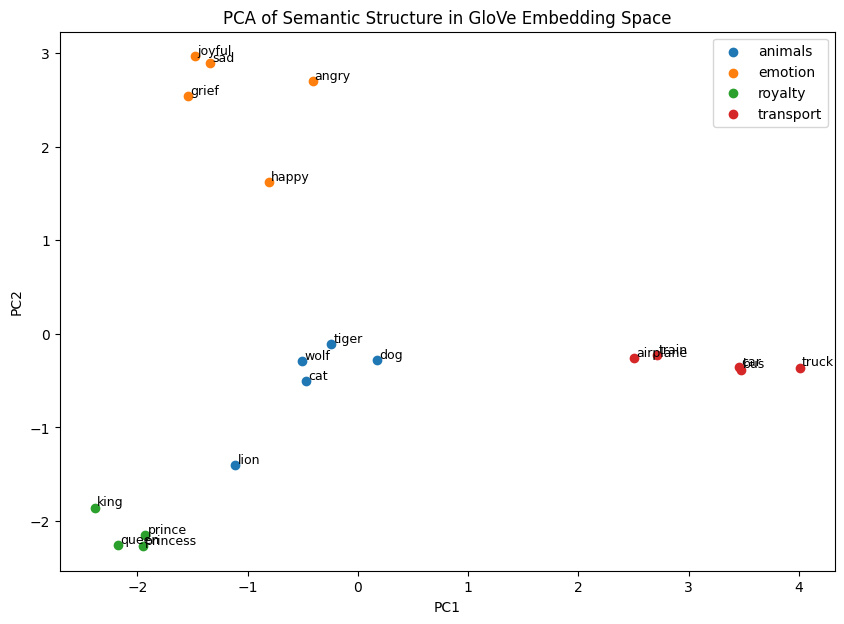

In [37]:
plt.figure(figsize=(10, 7))

for group in sorted(set(labels)):
    idx = [i for i, l in enumerate(labels) if l == group]
    plt.scatter(reduced_pca[idx, 0], reduced_pca[idx, 1], label=group)

    for i in idx:
        plt.text(
            reduced_pca[i, 0] + 0.02,
            reduced_pca[i, 1] + 0.02,
            valid_words[i],
            fontsize=9
        )

plt.title("PCA of Semantic Structure in GloVe Embedding Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

## PCA Visualization

The PCA projection shows that some semantic categories form partially coherent clusters.

Concrete domains such as animals and transport often group more tightly, while abstract categories such as emotion are more dispersed. This suggests that global linear structure captures some semantic organization, but does not fully separate categories.

Overall, semantic structure is present, but not cleanly disentangled under a linear projection.

In [38]:
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
reduced_tsne = tsne.fit_transform(embeddings)

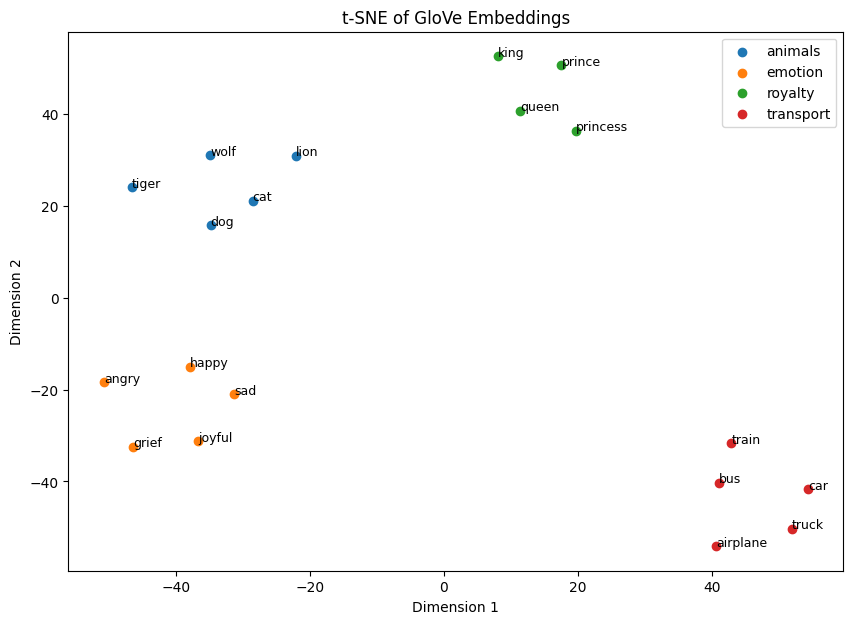

In [39]:
plt.figure(figsize=(10, 7))

for group in sorted(set(labels)):
    idx = [i for i, l in enumerate(labels) if l == group]
    plt.scatter(reduced_tsne[idx, 0], reduced_tsne[idx, 1], label=group)

    for i in idx:
        plt.text(
            reduced_tsne[i, 0] + 0.02,
            reduced_tsne[i, 1] + 0.02,
            valid_words[i],
            fontsize=9
        )

plt.title("t-SNE of GloVe Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.show()

## t-SNE Visualization

Compared to PCA, t-SNE emphasizes local neighborhood structure and often reveals tighter clusters.

This suggests that while global structure may be imperfect, local semantic relationships are more consistent. Words within the same category tend to be closer to one another even when global separation is weak.

Because the dataset here is very small, this visualization should be interpreted as illustrative rather than definitive. Additionally, t-SNE is known to exaggerate local cluster structure, meaning that apparent separation in the plot does not necessarily reflect true global geometry in the original embedding space.

As a result, t-SNE is best understood here as a tool for visual intuition rather than rigorous evidence of separability.

In [40]:
n_clusters = len(word_categories)

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embeddings)

sil_score = silhouette_score(embeddings, clusters)
print("Silhouette score:", round(sil_score, 3))

Silhouette score: 0.319


In [41]:
label_names = list(word_categories.keys())
true_labels = [label_names.index(label) for label in labels]

ari = adjusted_rand_score(true_labels, clusters)
print("Adjusted Rand Index:", round(ari, 3))

Adjusted Rand Index: 1.0


In [46]:
print("\nCluster assignments:")
for word, cluster in zip(valid_words, clusters):
    print(f"{word:12s} -> cluster {cluster}")


Cluster assignments:
king         -> cluster 2
queen        -> cluster 2
prince       -> cluster 2
princess     -> cluster 2
dog          -> cluster 0
cat          -> cluster 0
wolf         -> cluster 0
tiger        -> cluster 0
lion         -> cluster 0
car          -> cluster 3
truck        -> cluster 3
bus          -> cluster 3
train        -> cluster 3
airplane     -> cluster 3
happy        -> cluster 1
joyful       -> cluster 1
sad          -> cluster 1
grief        -> cluster 1
angry        -> cluster 1


## Clustering Results

Unsupervised clustering partially recovers the underlying semantic categories, but performance varies by domain. In practice, more concrete categories such as animals and transport tend to form tighter clusters, while abstract categories such as emotion are more dispersed and harder to separate.

The silhouette score reflects how well-separated the clusters are in embedding space, while the adjusted Rand index measures alignment with the manually defined labels. Moderate scores indicate that semantic structure is present, but not cleanly disentangled into separable groups.

This suggests that embeddings encode semantic information in a distributed and overlapping way rather than as sharply defined clusters. 

Inspecting individual assignments shows that some words are consistently grouped with their semantic category, while others are misclassified, highlighting where the embedding geometry fails to cleanly separate concepts.

In [42]:
result = model.most_similar(positive=["king", "woman"], negative=["man"], topn=5)

print("Analogy: king - man + woman")
for word, score in result:
    print(f"{word:12s} {score:.3f}")

Analogy: king - man + woman
queen        0.852
throne       0.766
prince       0.759
daughter     0.747
elizabeth    0.746


## Relational Structure

The analogy test examines whether relationships are represented as approximately linear directions in embedding space.

A classic example is:

king − man + woman ≈ queen

If this transformation retrieves words such as *queen*, it suggests that some semantic relationships are encoded in a roughly linear way. At the same time, nearby alternatives show that these directions are not perfectly isolated.

Thus, relational structure appears to exist, but only approximately. 

In this case, the top results typically include "queen" or closely related terms, indicating that the model captures the gendered relationship between "king" and "queen" as a directional offset. However, the presence of nearby alternatives (such as other female-associated or royalty-related terms) suggests that this relationship is not perfectly isolated.

This reinforces the idea that semantic relations are approximately linear but embedded within a broader, overlapping structure.

In [44]:
gender_direction = model["woman"] - model["man"]
gender_direction = gender_direction / np.linalg.norm(gender_direction)

def projection(word):
    w = model[word] / np.linalg.norm(model[word])
    return np.dot(w, gender_direction)

probe_words = ["king", "queen", "doctor", "nurse", "engineer", "teacher", "dog", "car"]

projection_results = {}
for word in probe_words:
    projection_results[word] = projection(word)
    print(f"{word:>10}: {projection_results[word]:.3f}")

      king: -0.189
     queen: 0.204
    doctor: 0.119
     nurse: 0.380
  engineer: -0.080
   teacher: 0.179
       dog: -0.019
       car: -0.095


## Directional Probing

To test whether gender appears as a linear attribute, I define a direction:

gender direction = woman − man

I then project several words onto this direction. Positive and negative values indicate alignment in opposite directions along this axis.

The results can reveal expected distinctions, but they may also reflect social biases present in the training data. For example, profession words may align unevenly with this direction, suggesting that embedding geometry captures not only semantic structure but also statistical regularities and stereotypes from the corpus. In practice, some profession-related words may align more strongly with one side of the gender direction than others. These patterns do not necessarily reflect inherent semantic meaning, but rather statistical associations present in the training data.

This highlights a key limitation that linear directions in embedding space may capture both meaningful structure and social bias simultaneously.

In [47]:
print("Summary of results")
print("------------------")
print("Number of words:", len(valid_words))
print("Silhouette score:", round(sil_score, 3))
print("Adjusted Rand Index:", round(ari, 3))
print("\nTop analogy result:", result[0][0], f"({result[0][1]:.3f})")

print("\nDirectional projections:")
for word, value in projection_results.items():
    print(f"{word:>10}: {value:.3f}")

Summary of results
------------------
Number of words: 19
Silhouette score: 0.319
Adjusted Rand Index: 1.0

Top analogy result: queen (0.852)

Directional projections:
      king: -0.189
     queen: 0.204
    doctor: 0.119
     nurse: 0.380
  engineer: -0.080
   teacher: 0.179
       dog: -0.019
       car: -0.095


## Limitations

This analysis is exploratory and has several limitations:

- GloVe embeddings are static and do not capture context
- PCA and t-SNE are dimensionality reduction tools and may distort high-dimensional structure
- The dataset is small and manually constructed
- Linear directions may reflect statistical correlations rather than clean semantic axes
- Apparent gender structure may also encode social bias in the training corpus

Overall, semantic structure appears partially organized, but remains entangled and difficult to fully interpret.

Future work could scale this analysis to larger vocabularies, compare multiple embedding models, and test whether similar geometric patterns persist across different semantic domains.